In [1]:
import pandas as pd
import numpy as np
import pycountry

In [2]:
# PyCountry mapping
records = []
for c in pycountry.countries:
    records.append({
        "country_name": c.name,
        "iso3":         c.alpha_3,
        "iso2":         c.alpha_2,
        "iso_numeric":  c.numeric,
    })

df_iso = pd.DataFrame(records)
print(df_iso.shape)
print(df_iso.head())

(249, 4)
    country_name iso3 iso2 iso_numeric
0          Aruba  ABW   AW         533
1    Afghanistan  AFG   AF         004
2         Angola  AGO   AO         024
3       Anguilla  AIA   AI         660
4  Åland Islands  ALA   AX         248


## PIP

In [3]:
df_pip = pd.read_csv("../Raw/imf_pip_v2.csv")
df_pip

,DATASET,SERIES_CODE,OBS_MEASURE,2017,2017-S1,2017-S2,2018,2018-S1,2018-S2,2019,...,2022,2022-S1,2022-S2,2023,2023-S1,2023-S2,2024,2024-S1,2024-S2,2025-S1
0,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.ATG.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.ISL.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.BHS.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.DZA.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.FRA.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2398383,IMF.STA:PIP(5.0.0),ROU.L.P_TOTINV_P_SCC_USD.S1.S1.CHE.S,OBS_VALUE,NaN,571.442313,564.17163,NaN,546.918514,596.559919,NaN,...,NaN,747.110799,891.041091,NaN,1110.745087,1180.474895,NaN,1291.454222,1337.448300,1500.694105
2398384,IMF.STA:PIP(5.0.0),ROU.L.P_TOTINV_P_SCC_USD.S1.S1.ZAF.S,OBS_VALUE,NaN,2.220104,2.59840,NaN,84.960486,50.637642,NaN,...,NaN,0.794509,0.941534,NaN,1.055030,0.000000,NaN,2.197700,2.027319,2.249668
2398385,IMF.STA:PIP(5.0.0),ROU.L.P_F51_P_SCC_USD.S1.S1.ARG.S,OBS_VALUE,NaN,0.000000,0.00000,NaN,0.000000,0.000000,NaN,...,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
2398386,IMF.STA:PIP(5.0.0),ROU.L.P_TOTINV_P_SCC_USD.S1.S1.BRA.S,OBS_VALUE,NaN,0.031647,NaN,NaN,NaN,0.071977,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.205699,0.232956


In [4]:
# We need to extract the country codes from the
# SERIES_CODE. So we will inspect the unique
# values to learn the pattern.
df_pip["SERIES_CODE"].sample(frac=1).iloc[:10].apply(lambda x: x.split(".")).values

array([list(['BEL', 'A', 'P_F51_P_USD', 'S123', 'S1', 'AUS', 'S']),
       list(['COK', 'L', 'P_F3_L_P_SCC_USD', 'S1', 'S1', 'BGR', 'S']),
       list(['BLR', 'A', 'P_F3_S_P_USD', 'S122', 'S1', 'UGA', 'S']),
       list(['SWE', 'A', 'P_F3_S_P_USD', 'S13', 'S1', 'BTN', 'A']),
       list(['MEX', 'A', 'P_TOTINV_P_USD', 'S1', 'S13', 'POL', 'S']),
       list(['HND', 'A', 'P_F3_L_P_USD', 'S1', 'S12', 'ATG', 'A']),
       list(['KWT', 'A', 'P_F51_P_USD', 'S11', 'S1', 'JOR', 'A']),
       list(['ZAF', 'A', 'P_F3_L_P_USD', 'S12R', 'S1', 'IRL', 'A']),
       list(['CZE', 'A', 'P_F51_P_USD', 'S1', 'S1', 'RUS', 'A']),
       list(['LIE', 'L', 'P_F3_L_P_SCC_USD', 'S1', 'S1', 'MKD', 'S'])],
      dtype=object)

In [5]:
# We need the first and sixth elements
# where the first is the origin country 
# and the sixth is the destination country.
df_pip["iso3_i"] = df_pip["SERIES_CODE"].apply(lambda x: x.split(".")[0])
df_pip["iso3_j"] = df_pip["SERIES_CODE"].apply(lambda x: x.split(".")[5])

df_pip[["SERIES_CODE", "iso3_i", "iso3_j"]].tail()

,SERIES_CODE,iso3_i,iso3_j
2398383,ROU.L.P_TOTINV_P_SCC_USD.S1.S1.CHE.S,ROU,CHE
2398384,ROU.L.P_TOTINV_P_SCC_USD.S1.S1.ZAF.S,ROU,ZAF
2398385,ROU.L.P_F51_P_SCC_USD.S1.S1.ARG.S,ROU,ARG
2398386,ROU.L.P_TOTINV_P_SCC_USD.S1.S1.BRA.S,ROU,BRA
2398387,TX983.L.P_F3_L_P_SCC_USD.S1.S1.PAN.S,TX983,PAN


In [6]:
df_pip[["iso3_i", "iso3_j", "SERIES_CODE"]].nunique()

iso3_i             247
iso3_j             247
SERIES_CODE    2389056
dtype: int64

In [7]:
# Now we need to melt the dataframe by
# getting the columns for each year.
yr_cols = [col for col in df_pip.columns if col.startswith("19") or col.startswith("20")]
yr_cols = [col for col in yr_cols if len(col)==4] # Only YYYY

df_pip_melted = df_pip.melt(id_vars=["SERIES_CODE", "iso3_i", "iso3_j"], value_vars=yr_cols, var_name="year", value_name="value")
# Replace 0 with nan
df_pip_melted["value"] = df_pip_melted["value"].replace(0, np.nan)
# Drop nans for value
df_pip_melted = df_pip_melted.dropna(subset=["value"])
# Drop duplicates by iso3_i, iso3_j, and year
df_pip_melted = df_pip_melted.drop_duplicates(subset=["iso3_i", "iso3_j", "year"])
df_pip_melted.describe()

,value
count,8.996100e+04
mean,6.638808e+03
std,1.075361e+05
min,-9.373819e+03
25%,1.120360e+00
50%,1.052352e+01
75%,1.093636e+02
max,6.606100e+06


In [8]:
df_pip_melted = df_pip_melted[["iso3_i", "iso3_j", "year", "value"]]
df_pip_melted

,iso3_i,iso3_j,year,value
387,CWX,DEU,2017,1.343000
390,CWX,GBR,2017,25.710000
398,CWX,NOR,2017,1.915000
427,CWX,BEL,2017,0.190000
428,CWX,SWE,2017,1.650000
...,...,...,...,...
19098398,TX983,DNK,2024,155.119069
19098414,TX983,JPN,2024,103.945040
19098465,TX983,SVN,2024,516.535885
19098482,TX983,MNG,2024,40.788969


In [9]:
df_pip_melted.to_csv("../Clean/IMF_PIP.csv", index=False)

## IIP

In [16]:
df_iip = pd.read_csv("../Raw/imf_iip.csv")
df_iip.head()

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FUNCTIONAL_CAT,SECTOR,SERIES_NAME,2012,2012-Q1,...,2024,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,IMF.STA:IIP(13.0.0),NIC.A_P.O_F2_S12R_NV.USD.A,OBS_VALUE,Nicaragua,"Other investment, Currency and deposits, Other...",NaN,NaN,NaN,NaN,NaN,...,1.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IMF.STA:IIP(13.0.0),NIC.L_P.O_F4_S13_NV.USD.A,OBS_VALUE,Nicaragua,"Other investment, Loans, General government",NaN,NaN,NaN,2337.300000,NaN,...,6793.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IMF.STA:IIP(13.0.0),NIC.L_P.O_F2_NV.USD.Q,OBS_VALUE,Nicaragua,"Other investment, Currency and deposits",NaN,NaN,NaN,NaN,404.3,...,NaN,28.5,32.3,35.5,32.0,NaN,32.8,NaN,NaN,NaN
3,IMF.STA:IIP(13.0.0),NIC.NETAL_P.NIIP_AFR.USD.A,OBS_VALUE,Nicaragua,"Net International Investment Position, Adjuste...",NaN,NaN,NaN,-10000.997938,NaN,...,-18259.494717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IMF.STA:IIP(13.0.0),NIC.A_P.O_F4_S1Z_S_NV.USD.Q,OBS_VALUE,Nicaragua,"Other investment, Loans, Other Sectors (BPM6),...",NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN


In [17]:
df_iip["INDICATOR"].value_counts().head(30)

INDICATOR
Other investment                                                                                                 968
International Investment Position                                                                                968
Other investment, Currency and deposits                                                                          966
Other investment, Loans                                                                                          958
Direct investment                                                                                                958
Portfolio investment                                                                                             955
Direct investment, Equity and investment fund shares                                                             938
Other investment, Currency and deposits, Deposit taking corporations, except the Central Bank                    936
Portfolio investment, Equity and investment fund share

In [11]:
# Keep only Liabilities (L_P), in USD, Annual (A) frequency
df_iip = df_iip[
    df_iip["SERIES_CODE"].str.contains(".L_P.", regex=False) & 
    df_iip["SERIES_CODE"].str.contains(".USD.", regex=False) & 
    df_iip["SERIES_CODE"].str.endswith(".A")
]

In [11]:
# Extract the iso3 from SERIES_CODE
df_iip["iso3"] = df_iip["SERIES_CODE"].apply(lambda x: x.split(".")[0])

In [12]:
# We want the following metrics
metrics = [
    "Portfolio investment, Equity and investment fund shares",
    "Portfolio investment, Debt securities"
]

# Make sure they both exist in dataframe
assert all(metric in df_iip["INDICATOR"].unique() for metric in metrics)

df_iip = df_iip[df_iip["INDICATOR"].isin(metrics)]

In [13]:
# Now get all the yr columns
yr_cols = [col for col in df_iip.columns if col.startswith("19") or col.startswith("20")]
yr_cols = [col for col in yr_cols if len(col)==4] # Only YYYY

df_iip_melted = df_iip.melt(id_vars=["SERIES_CODE", "iso3", "INDICATOR"], value_vars=yr_cols, var_name="year", value_name="value")
# Replace 0 with nan
df_iip_melted["value"] = df_iip_melted["value"].replace(0, np.nan)
# Drop nans for value
df_iip_melted = df_iip_melted.dropna(subset=["value"])
# Drop duplicates by iso3, INDICATOR, and year
df_iip_melted = df_iip_melted.drop_duplicates(subset=["iso3", "INDICATOR", "year"])

# Now sum the two indicators, but first assert that there is
# only one of each per year and country.
assert df_iip_melted.groupby(["iso3", "year", "INDICATOR"]).value_counts().max() == 1

df_iip_melted["value"] = df_iip_melted.groupby(["iso3", "year"])["value"].transform("sum")

df_iip_melted

,SERIES_CODE,iso3,INDICATOR,year,value
0,NIC.L_P.P_F3_MV.USD.A,NIC,"Portfolio investment, Debt securities",2012,21.466765
1,KHM.A_P.P_F3_MV.USD.A,KHM,"Portfolio investment, Debt securities",2012,445.975661
2,KHM.A_P.P_F5_MV.USD.A,KHM,"Portfolio investment, Equity and investment fu...",2012,445.975661
3,PHL.L_P.P_F5_MV.USD.A,PHL,"Portfolio investment, Equity and investment fu...",2012,47337.391640
4,IND.L_P.P_F5_MV.USD.A,IND,"Portfolio investment, Equity and investment fu...",2012,129012.208719
...,...,...,...,...,...
25696,SVN.A_P.P_F3_MV.USD.A,SVN,"Portfolio investment, Debt securities",2025,35657.477075
25730,MKD.A_P.P_F3_MV.USD.A,MKD,"Portfolio investment, Debt securities",2025,556.953239
25731,MKD.L_P.P_F5_MV.USD.A,MKD,"Portfolio investment, Equity and investment fu...",2025,556.953239
25738,NGA.L_P.P_F5_MV.USD.A,NGA,"Portfolio investment, Equity and investment fu...",2025,50123.756823


In [14]:
# Now to join to the pip data, we need to
# set iso3_i and iso3_j to the same value 
# as iso3 in the iip data.
df_iip_melted["iso3_i"] = df_iip_melted["iso3"]
df_iip_melted["iso3_j"] = df_iip_melted["iso3"]

In [15]:
df_iip_melted = df_iip_melted[["iso3_i", "iso3_j", "year", "value"]]

In [16]:
df_iip_melted.shape

(3972, 4)

## Merge

In [17]:
df_full = df_pip_melted.merge(df_iip_melted, on=["iso3_i", "iso3_j", "year"], how="outer")

df_full["value"] = df_full["value_x"].combine_first(df_full["value_y"])
df_full

,iso3_i,iso3_j,year,value_x,value_y,value
0,ABW,ABW,2012,NaN,569.254749,569.254749
1,ABW,ABW,2012,NaN,569.254749,569.254749
2,ABW,ABW,2013,NaN,554.000000,554.000000
3,ABW,ABW,2013,NaN,554.000000,554.000000
4,ABW,ABW,2014,NaN,621.100000,621.100000
...,...,...,...,...,...,...
93927,ZWE,ZAF,2020,7.830615,NaN,7.830615
93928,ZWE,ZAF,2021,343.845327,NaN,343.845327
93929,ZWE,ZAF,2022,286.932608,NaN,286.932608
93930,ZWE,ZAF,2023,263.266455,NaN,263.266455


In [34]:
df_full["year"] = df_full["year"].astype(int)
df_full["value"] = df_full["value"].astype(float)

In [35]:
# print number of same and non-same
same_cnt = (df_full["iso3_i"] == df_full["iso3_j"]).sum()
non_same_cnt = (df_full["iso3_i"] != df_full["iso3_j"]).sum()
print(f"Number of same: {same_cnt}")
print(f"Number of non-same: {non_same_cnt}")

Number of same: 3973
Number of non-same: 89959


In [36]:
df_full = df_full[["iso3_i", "iso3_j", "year", "value"]]

In [37]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 93932 entries, 0 to 93931
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   iso3_i  93932 non-null  str    
 1   iso3_j  93932 non-null  str    
 2   year    93932 non-null  int64  
 3   value   93932 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 2.9 MB


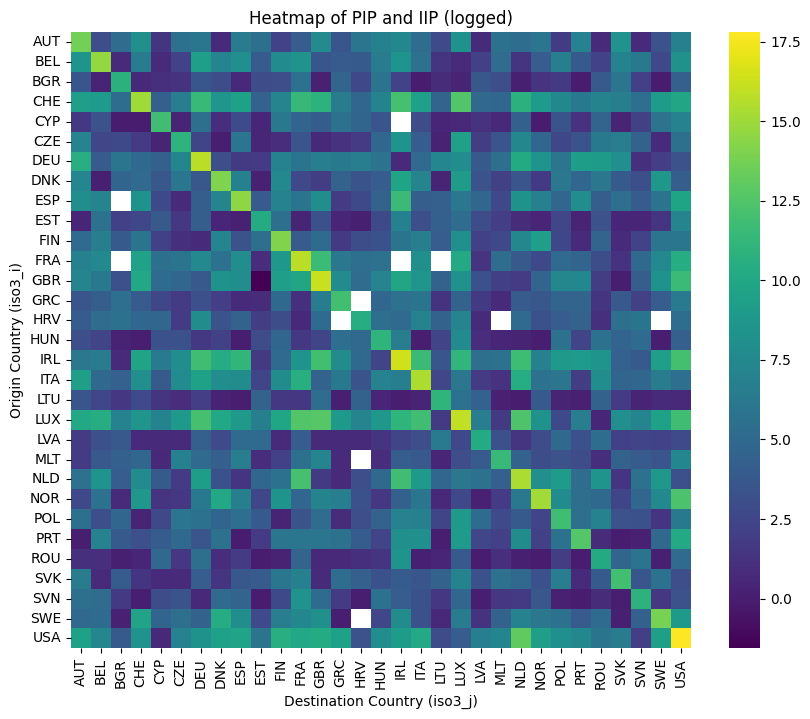

In [43]:
# plot a heatmap (logged)
import matplotlib.pyplot as plt
import seaborn as sns

EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC',
    'HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK',
    'SVN','ESP','SWE'
]
OUTSIDE = ['USA','GBR','CHE','NOR']
COUNTRIES = EU27 + OUTSIDE

df_eu = df_full[df_full["iso3_i"].isin(COUNTRIES) & df_full["iso3_j"].isin(COUNTRIES)].copy()
df_eu = df_eu[df_eu["year"] == 2024]

plt.figure(figsize=(10, 8))
sns.heatmap(df_eu.pivot_table(index="iso3_i", columns="iso3_j", values="value", aggfunc="sum").apply(np.log1p), cmap="viridis")
plt.title("Heatmap of PIP and IIP (logged)")
plt.xlabel("Destination Country (iso3_j)")
plt.ylabel("Origin Country (iso3_i)")
plt.show()

In [45]:
eu_pivot = df_eu.pivot_table(index="iso3_i", columns="iso3_j", values="value", aggfunc="sum")

# Get diagonal / row sum
eu_pivot["row_sum"] = eu_pivot.sum(axis=1)
eu_pivot["diag"] = np.diag(eu_pivot)
eu_pivot["diag_ratio"] = eu_pivot["diag"] / eu_pivot["row_sum"]
eu_pivot[["diag_ratio"]].sort_values("diag_ratio", ascending=False)

iso3_j,diag_ratio
iso3_i,
USA,0.986781
DEU,0.986232
FIN,0.985929
LTU,0.983527
BEL,0.983447
GBR,0.980919
GRC,0.979993
CYP,0.979433
ITA,0.976516
